# Previsão de Demanda na Cadeia de Suprimentos com Redes Neurais

**1. Contexto de negócio**

Uma empresa de varejo/logística precisa decidir, toda semana, quanto comprar ou produzir de um determinado produto. Duas coisas ruins podem acontecer:

- **Excesso de estoque**: capital parado, custo de armazenagem, risco de obsolescência/perda do produto.
- **Ruptura de estoque**: venda perdida, cliente insatisfeito, possível migração para o concorrente.

Uma previsão de demanda mais precisa ajuda o planejamento de compras/produção a equilibrar esses dois riscos. Neste notebook, simulamos uma série histórica de demanda semanal e comparamos uma baseline simples de planejamento com uma rede neural recorrente treinada para prever a demanda da próxima semana.

**2. Por que uma rede neural ajuda aqui?**

Séries de demanda costumam combinar padrões temporais distintos:

- **Tendência**: crescimento (ou queda) gradual ao longo do tempo.
- **Sazonalidade**: picos e vales que se repetem em ciclos (ex.: fim de ano, datas comemorativas).
- **Ruído**: variação aleatória do dia a dia do negócio.

Redes recorrentes como `SimpleRNN`/`LSTM` são projetadas para aprender dependências ao longo do tempo: recebem uma janela de semanas passadas e aprendem a combinar tendência + sazonalidade de forma não-linear para estimar a próxima semana. Métodos de planejamento mais simples (repetir o último valor, tirar uma média das últimas semanas) não conseguem capturar esse tipo de padrão combinado tão bem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


**3. Geração do dataset simulado**

Vamos simular **150 semanas** de demanda de um produto, combinando:

- Tendência de crescimento leve;
- Sazonalidade anual (ciclo de ~52 semanas, com pico próximo ao fim do ano);
- Ruído gaussiano.

Não há acesso a dados reais — tudo é gerado artificialmente com `numpy`, usando semente fixa (`np.random.seed(42)`) para reprodutibilidade.

In [2]:
N_WEEKS = 150
t = np.arange(N_WEEKS)

# Tendência de crescimento leve
trend = 500 + 1.4 * t

# Sazonalidade anual (ciclo de 52 semanas), com pico perto do fim do ano
sazonalidade = 90 * np.sin(2 * np.pi * (t - 13) / 52)

# Ruído gaussiano
ruido = np.random.normal(loc=0, scale=18, size=N_WEEKS)

demanda = trend + sazonalidade + ruido
demanda = np.clip(demanda, a_min=50, a_max=None)  # demanda não pode ser negativa

df = pd.DataFrame({"semana": t, "demanda": demanda})
df.head()

,semana,demanda
0,0,418.940855
1,1,409.567444
2,2,427.073630
3,3,447.463076
4,4,421.694197


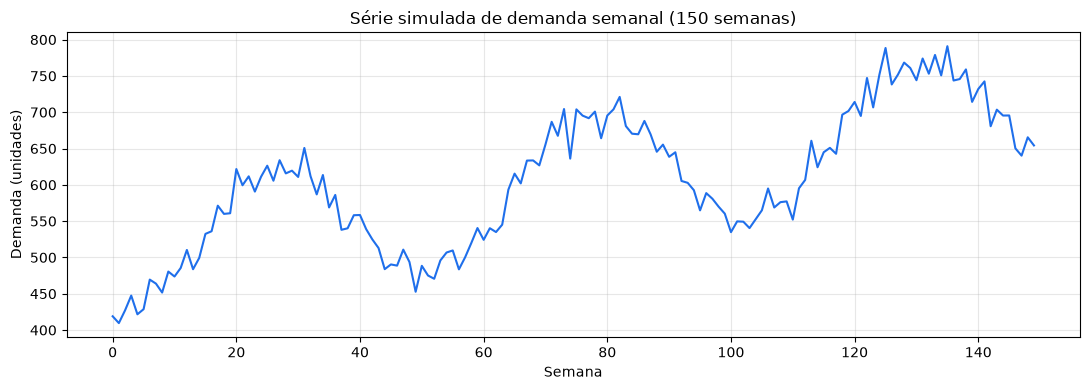

In [3]:
plt.figure(figsize=(11, 4))
plt.plot(df["semana"], df["demanda"], color="#1f6feb")
plt.title("Série simulada de demanda semanal (150 semanas)")
plt.xlabel("Semana")
plt.ylabel("Demanda (unidades)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**4. Construção dos exemplos: janelas deslizantes**

Para treinar um modelo supervisionado a partir de uma série temporal, transformamos a série em pares (janela de entrada, valor a prever):

- Entrada: as últimas **N = 8** semanas de demanda;
- Saída: a demanda da semana seguinte.

Isso é feito deslizando uma janela de tamanho N sobre toda a série.

In [4]:
N = 8  # tamanho da janela (semanas usadas para prever a próxima)

def montar_janelas(serie, n):
    X, y, semanas_alvo = [], [], []
    for i in range(len(serie) - n):
        X.append(serie[i:i + n])
        y.append(serie[i + n])
        semanas_alvo.append(i + n)
    return np.array(X), np.array(y), np.array(semanas_alvo)

X, y, semanas_alvo = montar_janelas(demanda, N)
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (142, 8)
Formato de y: (142,)


**5. Separação treino/teste respeitando a ordem temporal**

Diferente de problemas tabulares comuns, **não podemos embaralhar** os dados: o teste precisa representar o "futuro" em relação ao treino. Vamos reservar as últimas 30 janelas (últimas semanas da série) como conjunto de teste, e usar tudo antes disso para treino.

In [5]:
TEST_SIZE = 30

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]
semanas_train, semanas_test = semanas_alvo[:-TEST_SIZE], semanas_alvo[-TEST_SIZE:]

print("Treino:", X_train.shape, y_train.shape)
print("Teste: ", X_test.shape, y_test.shape)

Treino: (112, 8) (112,)
Teste:  (30, 8) (30,)


**6. Baseline de planejamento: média móvel**

Uma prática comum e simples de planejamento é estimar a demanda da próxima semana como a **média das últimas N semanas** (média móvel). É um método fácil de explicar e implementar, usado como referência para saber se vale a pena investir em um modelo mais sofisticado.

In [6]:
baseline_pred = X_test.mean(axis=1)  # média das N semanas da janela

mae_baseline = mean_absolute_error(y_test, baseline_pred)
print(f"MAE da baseline (média móvel): {mae_baseline:.2f} unidades")

MAE da baseline (média móvel): 32.13 unidades


**7. Modelo de rede neural (SimpleRNN)**

Agora treinamos uma rede neural recorrente pequena (`SimpleRNN`) para a mesma tarefa: receber a janela de N semanas e prever a demanda da semana seguinte.

Antes de treinar, normalizamos os valores para a faixa [0, 1] (comum em redes neurais, ajuda a convergência), usando um `MinMaxScaler` ajustado **apenas nos dados de treino**, para não vazar informação do teste.

In [7]:
scaler = MinMaxScaler()
scaler.fit(y_train.reshape(-1, 1))

X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train_scaled = scaler.transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()

# Formato exigido pelas camadas recorrentes: (amostras, passos_no_tempo, features)
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], N, 1))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], N, 1))

print("Formato de entrada da RNN (treino):", X_train_rnn.shape)

Formato de entrada da RNN (treino): (112, 8, 1)


In [8]:
modelo = keras.Sequential([
    layers.SimpleRNN(32, activation="tanh", input_shape=(N, 1)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])

modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])

historico = modelo.fit(
    X_train_rnn, y_train_scaled,
    epochs=100,
    batch_size=8,
    verbose=0,
)

print("Treinamento concluído. Última perda (MSE, escala normalizada):", round(historico.history["loss"][-1], 5))

/private/tmp/claude-501/-Users-marcofidos-GitHub/eeac8253-df86-407b-b3e0-06b2333596a4/scratchpad/nbviz-venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinamento concluído. Última perda (MSE, escala normalizada): 0.00546


In [9]:
y_pred_scaled = modelo.predict(X_test_rnn, verbose=0).flatten()
y_pred_rnn = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
print(f"MAE da rede neural (SimpleRNN): {mae_rnn:.2f} unidades")

MAE da rede neural (SimpleRNN): 23.47 unidades


**8. Comparação lado a lado**

Vamos comparar o erro absoluto médio (MAE) das duas abordagens no mesmo conjunto de teste (últimas 30 semanas, fora do treino).

In [10]:
comparacao = pd.DataFrame({
    "Método": ["Baseline (média móvel)", "Rede neural (SimpleRNN)"],
    "MAE (unidades)": [mae_baseline, mae_rnn],
})
comparacao["MAE (unidades)"] = comparacao["MAE (unidades)"].round(2)
comparacao

,Método,MAE (unidades)
0,Baseline (média móvel),32.13
1,Rede neural (SimpleRNN),23.47


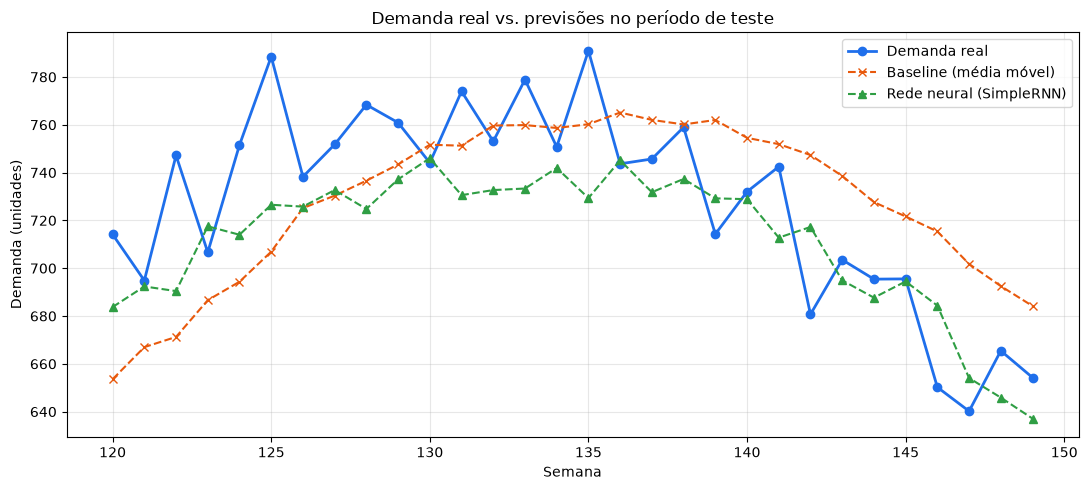

In [11]:
plt.figure(figsize=(11, 5))
plt.plot(semanas_test, y_test, label="Demanda real", color="#1f6feb", marker="o", linewidth=2)
plt.plot(semanas_test, baseline_pred, label="Baseline (média móvel)", color="#e8590c", linestyle="--", marker="x")
plt.plot(semanas_test, y_pred_rnn, label="Rede neural (SimpleRNN)", color="#2f9e44", linestyle="--", marker="^")
plt.title("Demanda real vs. previsões no período de teste")
plt.xlabel("Semana")
plt.ylabel("Demanda (unidades)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**9. Conclusão qualitativa**

Os números exatos de MAE calculados acima devem ser lidos com cautela: os dados são 100% simulados, a rede é pequena e o treinamento é rápido (poucas épocas), propositalmente, para fins didáticos.

Pontos que valem a reflexão para um caso real de cadeia de suprimentos:

- Uma rede recorrente só tende a compensar o esforço extra de implementação/manutenção quando existe **padrão temporal não-linear real** (sazonalidade combinada com tendência, múltiplas sazonalidades, efeitos de calendário) que uma baseline simples não capture bem.
- Com poucas semanas de histórico (como aqui, 150 semanas ≈ menos de 3 ciclos anuais completos), o modelo tem pouquíssimos exemplos de cada "fase" da sazonalidade — em um cenário real, seria recomendável mais histórico, variáveis exógenas (promoções, preço, feriados) e validação mais robusta antes de substituir um processo de planejamento já em uso.
- Do ponto de vista de negócio, a métrica MAE deve sempre ser traduzida em impacto financeiro (custo de estoque parado vs. custo de ruptura) antes de decidir qual modelo colocar em produção — o menor MAE nem sempre é a escolha de menor risco operacional.